# EDA on LIWC Features

Coco Yu  
October 7, 2024

## Code Status

## Notes

## Setup

Chunk Defaults

In [ ]:
knitr::opts_chunk$set(attr.output='style="max-height: 500px;"')


Conflicts

In [ ]:
options(conflicts.policy = "depends.ok")


In [ ]:
library(tidyverse)


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.3     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.4.3     ✔ tibble    3.2.1
✔ lubridate 1.9.2     ✔ tidyr     1.3.0
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

here() starts at /Users/yujiachen/Desktop/github/study_messages

Source Functions

In [ ]:
devtools::source_url("https://github.com/jjcurtin/lab_support/blob/main/format_path.R?raw=true")


ℹ SHA-1 hash of file is "a58e57da996d1b70bb9a5b58241325d6fd78890f"

ℹ SHA-1 hash of file is "c045eee2655a18dc85e715b78182f176327358a7"

Absolute Paths

In [ ]:
path_messages <- format_path(str_c("studydata/risk/data_processed/messages"))


Read in Data

In [ ]:
liwc_ind <- read_csv(
  here(path_messages, "liwc", "liwc_features_long.csv"),
  col_types = cols()
)

liwc_cat <- read_csv(
  here(path_messages, "liwc", "liwc_features_cat.csv"),
  col_types = cols()
)


## EDA on liwc features generated on individual messages

sanity check: number of participants

In [ ]:
liwc_ind |> 
  pull(subid) |> 
  unique() |> 
  length()


[1] 138

sanity check: \# of labels

In [ ]:
(nrow(liwc_ind))


[1] 11562

sanity check: \# of labels per participant (same with raw_message file)

In [ ]:
liwc_ind |> 
  group_by(subid) |> 
  summarize(n = n()) |> 
  summarize(
    mean = mean(n),
    sd = sd(n),
    median = median(n),
    min = min(n),
    max = max(n)
  )


# A tibble: 1 × 5
   mean    sd median   min   max
  <dbl> <dbl>  <dbl> <int> <int>
1  83.8  11.4     88    30    90

sanity check: \# of features for each prediction window

In [ ]:
liwc_ind |> 
  select(ends_with("3day")) |> 
  ncol()


[1] 234

[1] 234

[1] 468

### sanity check: missingness

> **By lapse labels**

> checked the percentage of labels that lack liwc features match missingness on raw messages for 3day, and 1week prediction windows

> checked that the percentage of labels that lack liwc features in 1week prediction window and combined feature sets match (both 7.83%)

In [ ]:
liwc_ind |> 
  select(ends_with("3day")) |> 
  rowwise() |> 
  mutate(na = if_else(all(is.na(across(everything()))), 1, 0)) |> 
  ungroup() |>
  pull(na) |> 
  mean()


[1] 0.1191835

[1] 0.07827366

[1] 0.07827366

> **By subject**

> checked the percentage of missingness per participant match between raw messages and liwc features for 3day and 1week prediction windows separately

> checked that the missingness per participant in 1week prediction window and combined feature sets match

In [ ]:
liwc_ind |> 
  select(ends_with("3day"), subid, day_start) |> 
  group_by(subid, day_start) |> 
  summarize(
    missingness = if_else(all(is.na(across(everything()))), 1, 0)
  ) |> 
  group_by(subid) |> 
  summarize(
    mean_missing = mean(missingness)
  ) |> 
  summarize(
    mean_mean_missing = mean(mean_missing),
    sd_mean_missing = sd(mean_missing),
    median_mean_missing = median(mean_missing),
    min_mean_missing = min(mean_missing),
    max_mean_missing = max(mean_missing)
  ) |> 
  print_kbl()


`summarise()` has grouped output by 'subid'. You can override using the
`.groups` argument.

`summarise()` has grouped output by 'subid'. You can override using the
`.groups` argument.

`summarise()` has grouped output by 'subid'. You can override using the
`.groups` argument.

### EDA on features

In [ ]:
skim_minimal <- skimr::skim_with(numeric = skimr::sfl(mean = NULL, p25 = NULL, 
                                                      p75 = NULL, 
                                                      hist = NULL))

stats_ind <- liwc_ind |> 
  select(ends_with("3day"), ends_with("1week")) |> 
  skim_minimal() |> 
  select(-n_missing)

stats_ind |> 
  arrange(numeric.sd, numeric.p50) |> 
  print_kbl()


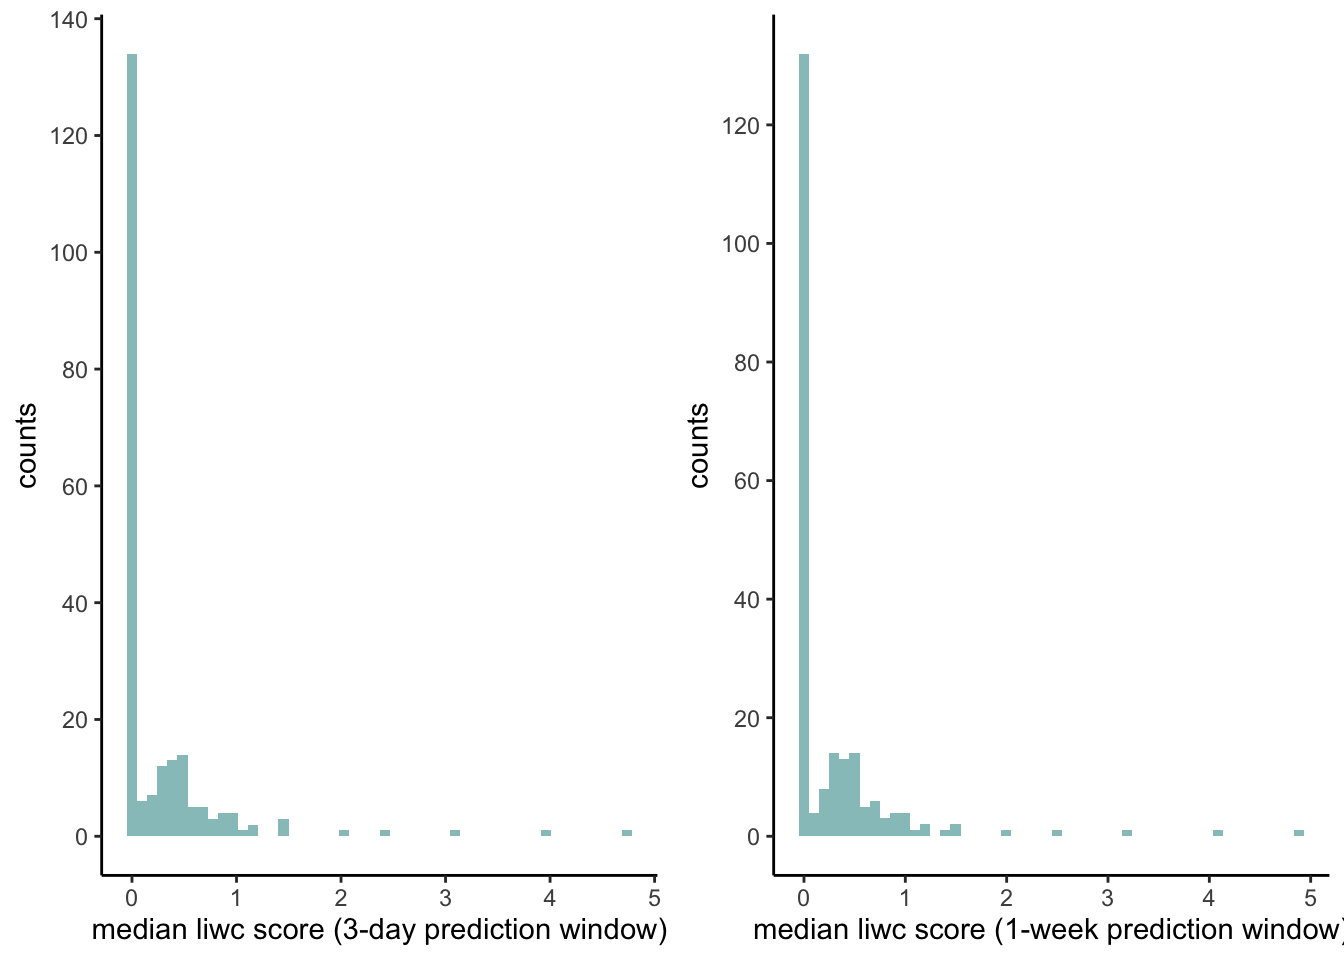

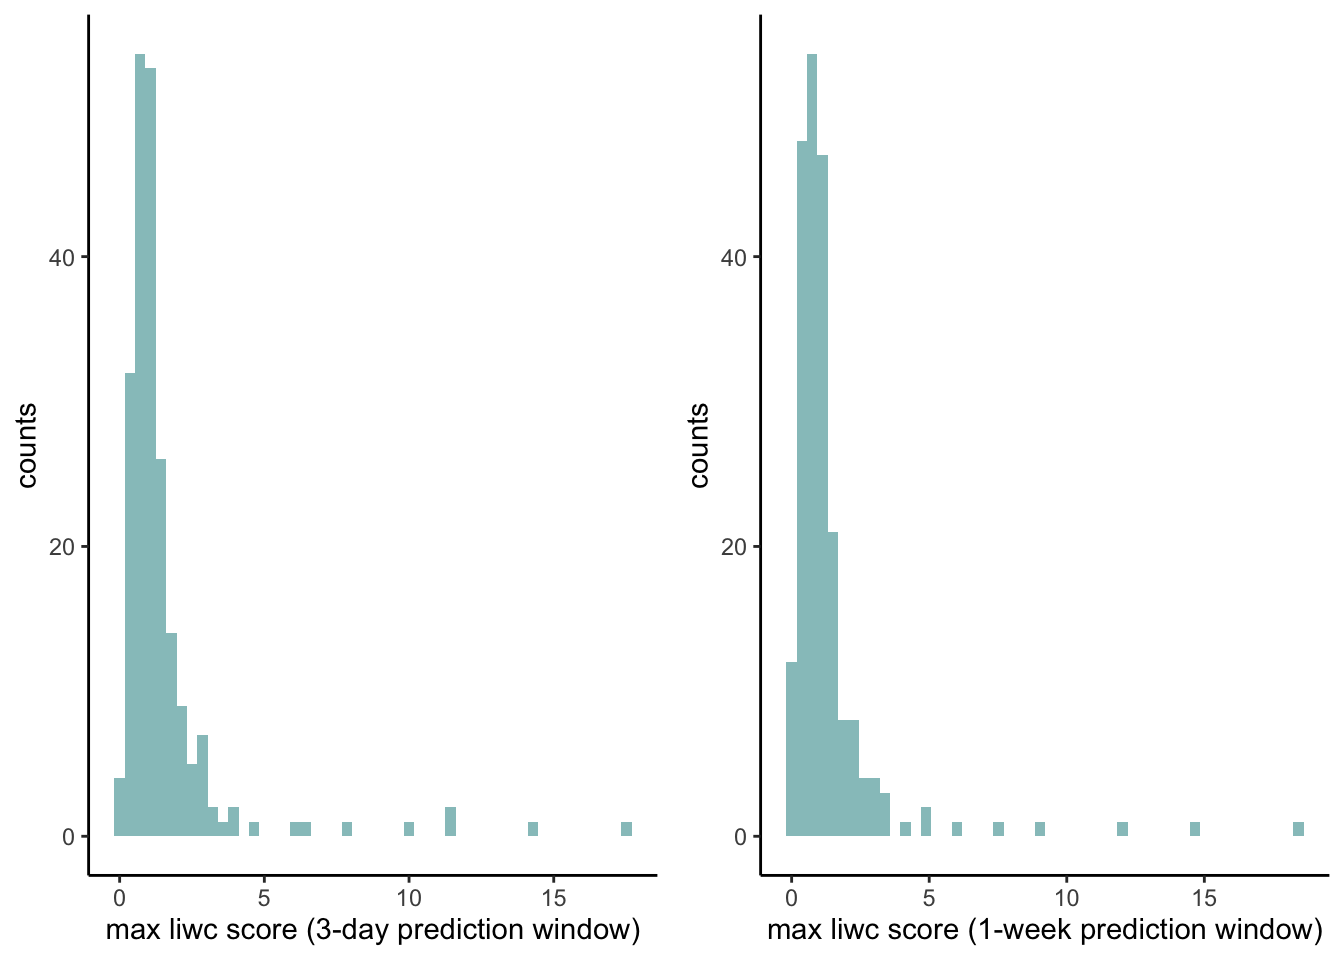

In [ ]:
cowplot::plot_grid(
  stats_ind |> 
    filter(!str_detect(skim_variable, "wc|wps|analytic|tone|clout|authentic")) |>
    filter(str_detect(skim_variable, "3day")) |> 
    # filter(numeric.p50 != 0) |> 
    ggplot(aes(x = numeric.p50)) +
    geom_histogram(fill = "#97C4C5", bins = 50) +
    scale_y_continuous(breaks = seq(0, 160, by = 20)) +
    labs(x = "median liwc score (3-day prediction window)", y = "counts"),
  stats_ind |> 
    filter(!str_detect(skim_variable, "wc|wps|analytic|tone|clout|authentic")) |>
    filter(str_detect(skim_variable, "1week")) |> 
    # filter(numeric.p50 != 0) |> 
    ggplot(aes(x = numeric.p50)) +
    geom_histogram(fill = "#97C4C5", bins = 50) +
    scale_y_continuous(breaks = seq(0, 160, by = 20)) +
    labs(x = "median liwc score (1-week prediction window)", y = "counts")
)


## EDA on concatenated messages

sanity check: number of participants

In [ ]:
liwc_cat |> 
  pull(subid) |> 
  unique() |> 
  length()


[1] 138

sanity check: \# of labels

In [ ]:
(nrow(liwc_cat))


[1] 11562

sanity check: \# of labels per participant (same with raw_message file)

In [ ]:
liwc_cat |> 
  group_by(subid) |> 
  summarize(n = n()) |> 
  summarize(
    mean = mean(n),
    sd = sd(n),
    median = median(n),
    min = min(n),
    max = max(n)
  )


# A tibble: 1 × 5
   mean    sd median   min   max
  <dbl> <dbl>  <dbl> <int> <int>
1  83.8  11.4     88    30    90

sanity check: \# of features for each prediction window

In [ ]:
liwc_cat |> 
  select(ends_with("3day")) |> 
  ncol()


[1] 234

[1] 234

[1] 468

### sanity check: missingness

> **By lapse labels**

> checked the percentage of labels that lack liwc features match missingness on raw messages for 3day, and 1week prediction windows

> checked that the percentage of labels that lack liwc features in 1week prediction window and combined feature sets match (both 7.83%)

In [ ]:
liwc_cat |> 
  select(ends_with("3day")) |> 
  rowwise() |> 
  mutate(na = if_else(all(is.na(across(everything()))), 1, 0)) |> 
  ungroup() |>
  pull(na) |> 
  mean()


[1] 0.1191835

[1] 0.07827366

[1] 0.07827366

> **By subject**

> checked the percentage of missingness per participant match between raw messages and liwc features for 3day and 1week prediction windows separately

> checked that the missingness per participant in 1week prediction window and combined feature sets match

In [ ]:
liwc_cat |> 
  select(ends_with("3day"), subid, day_start) |> 
  group_by(subid, day_start) |> 
  summarize(
    missingness = if_else(all(is.na(across(everything()))), 1, 0)
  ) |> 
  group_by(subid) |> 
  summarize(
    mean_missing = mean(missingness)
  ) |> 
  summarize(
    mean_mean_missing = mean(mean_missing),
    sd_mean_missing = sd(mean_missing),
    median_mean_missing = median(mean_missing),
    min_mean_missing = min(mean_missing),
    max_mean_missing = max(mean_missing)
  ) |> 
  print_kbl()


`summarise()` has grouped output by 'subid'. You can override using the
`.groups` argument.

`summarise()` has grouped output by 'subid'. You can override using the
`.groups` argument.

`summarise()` has grouped output by 'subid'. You can override using the
`.groups` argument.

### EDA on features

In [ ]:
stats_cat <- liwc_cat |> 
  select(ends_with("3day"), ends_with("1week")) |> 
  skim_minimal() |> 
  select(-n_missing)

stats_cat |> 
  arrange(numeric.sd, numeric.p50) |> 
  print_kbl()


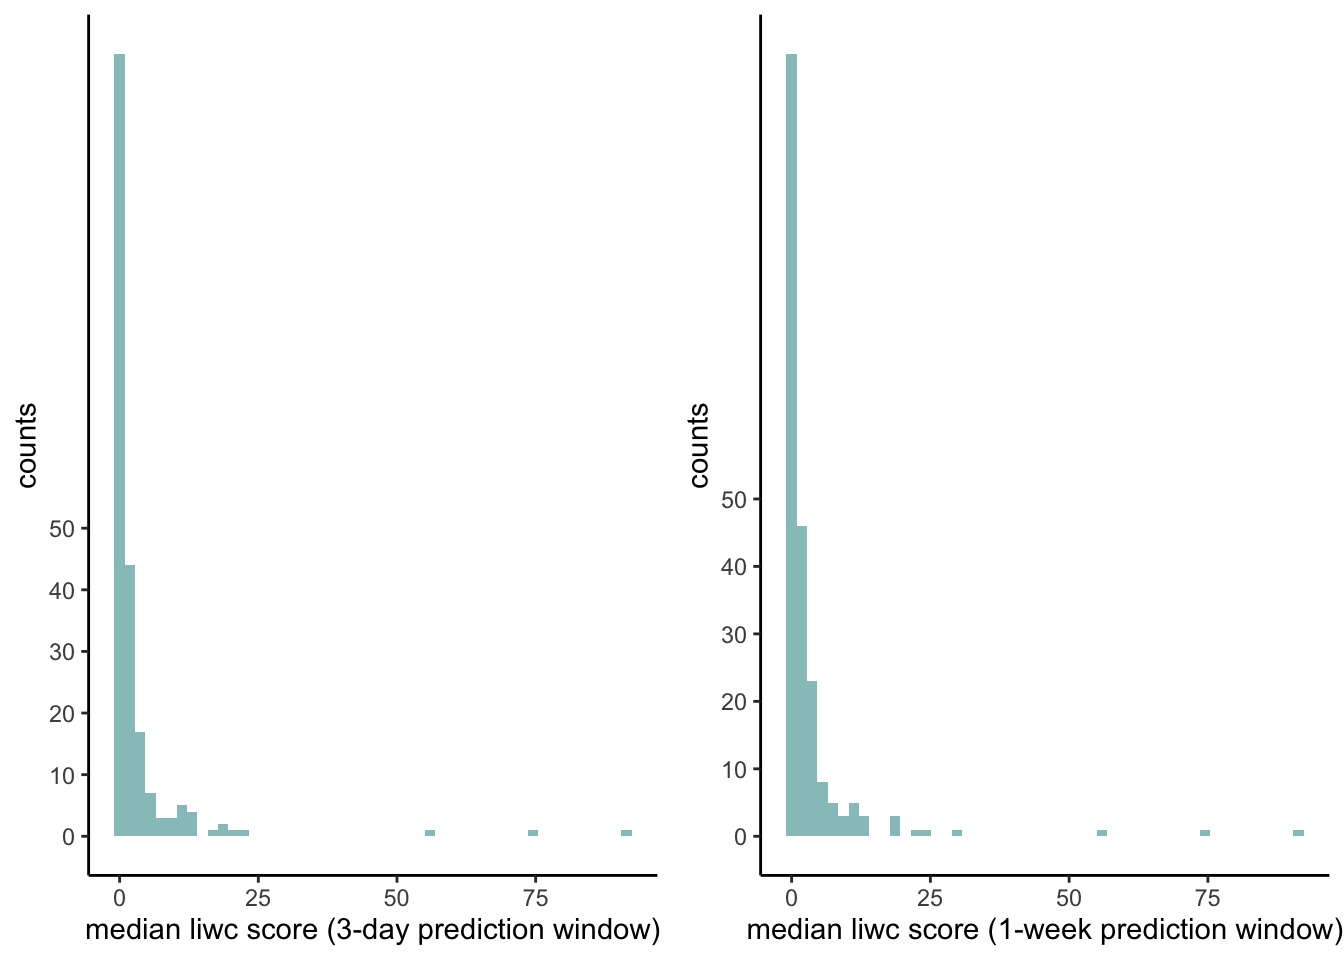

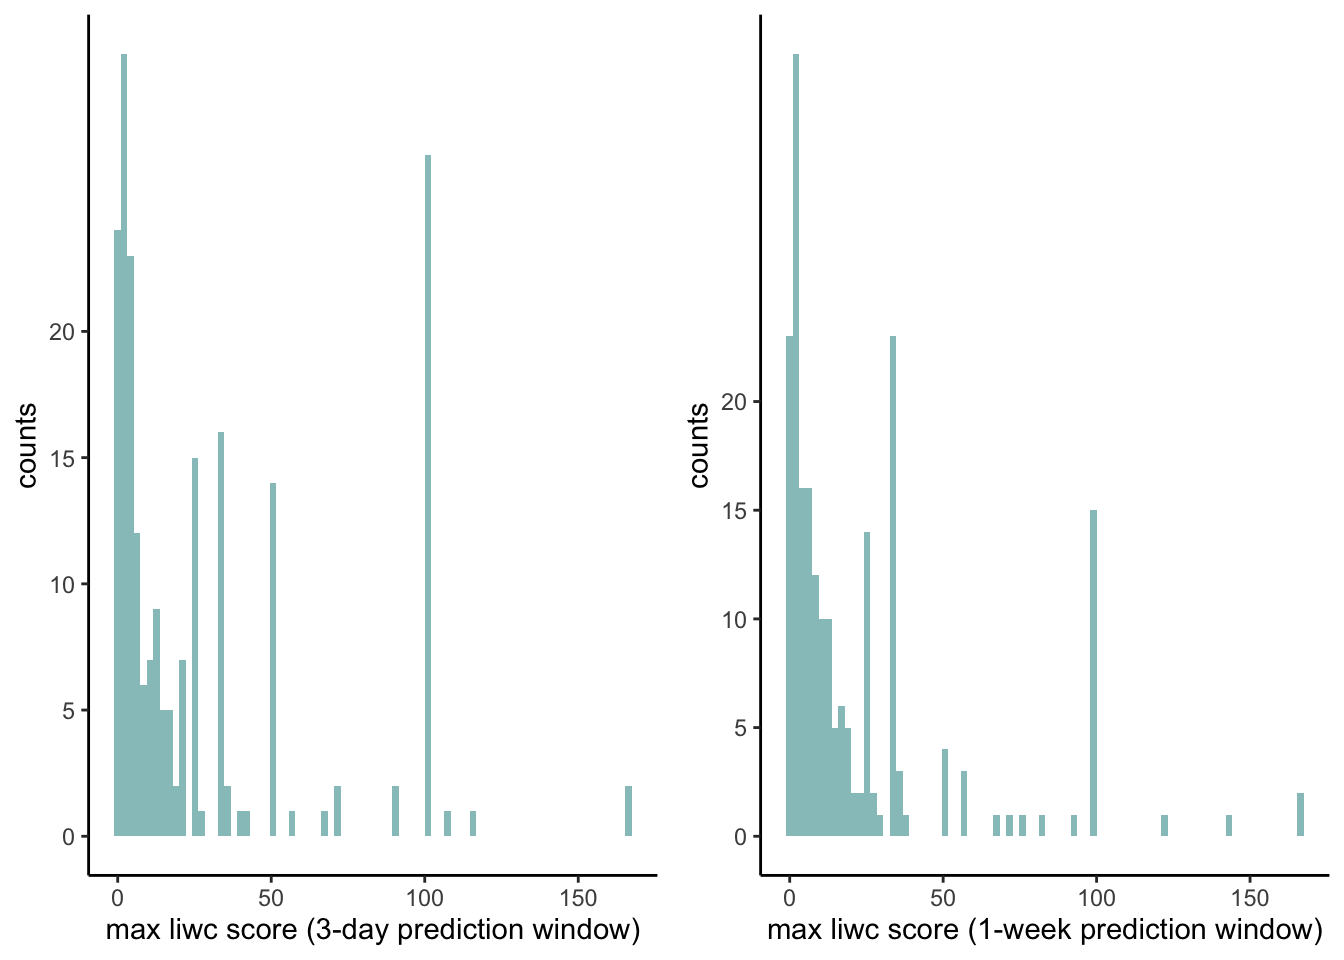

In [ ]:
cowplot::plot_grid(
  stats_cat |> 
    filter(!str_detect(skim_variable, "wc|wps|analytic|tone|clout|authentic")) |>
    filter(str_detect(skim_variable, "3day")) |> 
    # filter(numeric.p50 != 0) |> 
    ggplot(aes(x = numeric.p50)) +
    geom_histogram(fill = "#97C4C5", bins = 50) +
    scale_y_continuous(breaks = seq(0, 50, by = 10)) +
    labs(x = "median liwc score (3-day prediction window)", y = "counts"),
  stats_cat |> 
    filter(!str_detect(skim_variable, "wc|wps|analytic|tone|clout|authentic")) |>
    filter(str_detect(skim_variable, "1week")) |> 
    # filter(numeric.p50 != 0) |> 
    ggplot(aes(x = numeric.p50)) +
    geom_histogram(fill = "#97C4C5", bins = 50) +
    scale_y_continuous(breaks = seq(0, 50, by = 10)) +
    labs(x = "median liwc score (1-week prediction window)", y = "counts")
)
